# Initial Baseline, with data exploration

In [32]:
from pathlib import Path
import sys
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from torchvision import transforms
from src.dataset.dataframe_creator import generate_df
from src.dataset.folders_creator import FoldersCreator
from src.dataset.data_pipeline import DataPipeline

PROJECT_ROOT = Path.cwd()
sys.path.append(str(PROJECT_ROOT / "src"))


In [33]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using device:", device)

Using device: mps


In [34]:
PROJECT_ROOT = Path.cwd().resolve()
for p in [PROJECT_ROOT] + list(PROJECT_ROOT.parents):
    if (p / "src").exists() and (p / "data").exists():
        PROJECT_ROOT = p
        break

SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

TRAIN_PATH = PROJECT_ROOT / "data"/ "iivp-2026-challenge" / "train"/"train"
TEST_PATH = PROJECT_ROOT / "data" / "iivp-2026-challenge" / "test"/"test"

print("Project root:", PROJECT_ROOT)
print("Train path:", TRAIN_PATH)
print("Test path:", TEST_PATH)
print("Train exists:", TRAIN_PATH.exists())
print("Test exists:", TEST_PATH.exists())

Project root: /Users/nickgrebe/Desktop/DSAI_YEAR2/Periode 5/Image&VideoProcessing/Challenge
Train path: /Users/nickgrebe/Desktop/DSAI_YEAR2/Periode 5/Image&VideoProcessing/Challenge/data/iivp-2026-challenge/train/train
Test path: /Users/nickgrebe/Desktop/DSAI_YEAR2/Periode 5/Image&VideoProcessing/Challenge/data/iivp-2026-challenge/test/test
Train exists: True
Test exists: True


In [35]:
DATASET_PATH = TRAIN_PATH

df = generate_df(DATASET_PATH)

print(df.head())
print(df.columns)
print("Number of samples:", len(df))
if "label" in df.columns:
    print(df["label"].value_counts().sort_index())

fold_creator = FoldersCreator(df, n_splits=5)
folds_path = PROJECT_ROOT / "data" / "folds.csv"
df = fold_creator.create_folds(output_path=folds_path)
print("Saved folds to:", folds_path)

FOLD = 0
train_df = df[df["fold"] != FOLD].reset_index(drop=True)
val_df = df[df["fold"] == FOLD].reset_index(drop=True)

transforms_dict = {
    "train": transforms.Compose([
        transforms.Resize((28, 28)),
        transforms.ToTensor(),
    ]),
    "validation": transforms.Compose([
        transforms.Resize((28, 28)),
        transforms.ToTensor(),
    ]),
}

pipeline = DataPipeline(train_df, val_df, transforms_dict)
train_loader, val_loader = pipeline.get_loaders(batch_size=64)

images, labels = next(iter(train_loader))
print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print(df.head())
print("Train dataframe shape:", train_df.shape)
print("Validation dataframe shape:", val_df.shape)

                                                path  label
0  /Users/nickgrebe/Desktop/DSAI_YEAR2/Periode 5/...      0
1  /Users/nickgrebe/Desktop/DSAI_YEAR2/Periode 5/...      0
2  /Users/nickgrebe/Desktop/DSAI_YEAR2/Periode 5/...      0
3  /Users/nickgrebe/Desktop/DSAI_YEAR2/Periode 5/...      0
4  /Users/nickgrebe/Desktop/DSAI_YEAR2/Periode 5/...      0
Index(['path', 'label'], dtype='str')
Number of samples: 17000
label
0    1700
1    1700
2    1700
3    1700
4    1700
5    1700
6    1700
7    1700
8    1700
9    1700
Name: count, dtype: int64
Saved folds to: /Users/nickgrebe/Desktop/DSAI_YEAR2/Periode 5/Image&VideoProcessing/Challenge/data/folds.csv
Images shape: torch.Size([64, 1, 28, 28])
Labels shape: torch.Size([64])
                                                path  label  fold
0  /Users/nickgrebe/Desktop/DSAI_YEAR2/Periode 5/...      0     4
1  /Users/nickgrebe/Desktop/DSAI_YEAR2/Periode 5/...      0     0
2  /Users/nickgrebe/Desktop/DSAI_YEAR2/Periode 5/...      0     0

In [36]:
# Constants
NUM_CLASSES = len(df["label"].unique())
EPOCHS = 10

The following architecture is one that i used some time ago, it is quite large for a baseline, but without any tuning I got it well into the 90% accuracy when i first tried it!

In [37]:
class initial_CNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3),
            nn.ReLU(),
            nn.BatchNorm2d(32),

            nn.Conv2d(32, 32, kernel_size=3),
            nn.ReLU(),
            nn.BatchNorm2d(32),

            # This layer seems odd, but is actually quite cool, as it looks at a larger neighborhood extracting features that go beyond a 3x3 kernel. Like in NLP giving a broader context!
            nn.Conv2d(32, 32, kernel_size=5, stride=2, padding=2),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.Dropout(0.4),

            # And zooming in back onto the more fine grained details!
            # Here we also remove the padding again so w
            nn.Conv2d(32, 64, kernel_size=3),
            nn.ReLU(),
            nn.BatchNorm2d(64),

            nn.Conv2d(64, 64, kernel_size=3) ,
            nn.ReLU(),
            nn.BatchNorm2d(64),

            nn.Conv2d(64, 64, kernel_size=5, stride=2, padding=2),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.Dropout(0.4),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 4 * 4, 128), # output chanels, chanel amouunt, chanel size
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [38]:
model = initial_CNN(num_classes=NUM_CLASSES).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(model)

initial_CNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
    (4): ReLU()
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): Conv2d(32, 32, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (7): ReLU()
    (8): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): Dropout(p=0.4, inplace=False)
    (10): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (11): ReLU()
    (12): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
    (14): ReLU()
    (15): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (16): Conv2d(64, 64, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (

In [39]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

Epoch 1/10 | train_loss=0.3522, train_acc=0.9021 | val_loss=0.0501, val_acc=0.9868
Epoch 2/10 | train_loss=0.0594, train_acc=0.9844 | val_loss=0.0367, val_acc=0.9882
Epoch 3/10 | train_loss=0.0344, train_acc=0.9912 | val_loss=0.0205, val_acc=0.9941
Epoch 4/10 | train_loss=0.0299, train_acc=0.9916 | val_loss=0.0184, val_acc=0.9950
Epoch 5/10 | train_loss=0.0229, train_acc=0.9935 | val_loss=0.0274, val_acc=0.9924
Epoch 6/10 | train_loss=0.0151, train_acc=0.9958 | val_loss=0.0165, val_acc=0.9959
Epoch 7/10 | train_loss=0.0139, train_acc=0.9959 | val_loss=0.0174, val_acc=0.9953
Epoch 8/10 | train_loss=0.0141, train_acc=0.9958 | val_loss=0.0230, val_acc=0.9932
Epoch 9/10 | train_loss=0.0150, train_acc=0.9953 | val_loss=0.0134, val_acc=0.9968
Epoch 10/10 | train_loss=0.0156, train_acc=0.9955 | val_loss=0.0150, val_acc=0.9965


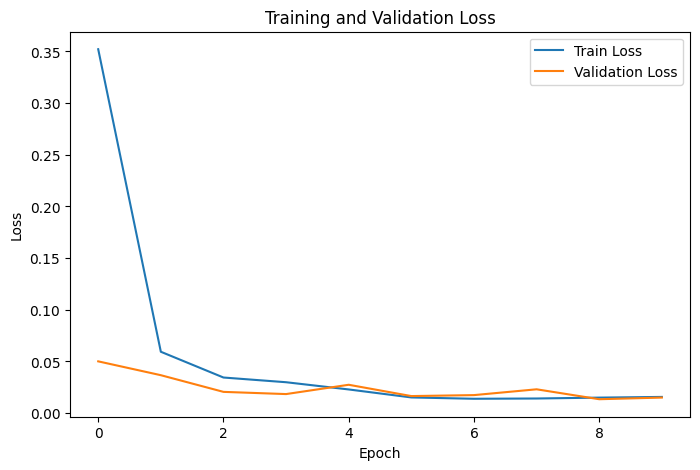

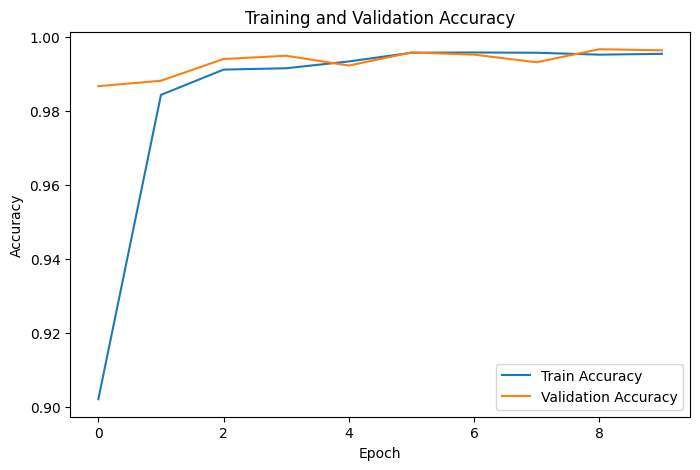

In [40]:
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate_one_epoch(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}"
    )

plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

# Plot accuracy
plt.figure(figsize=(8, 5))
plt.plot(history["train_acc"], label="Train Accuracy")
plt.plot(history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

In [42]:
print("The final accuracy is: ", history["val_acc"][-1])

The final accuracy is:  0.9964705882352941


This is actually a very very nice result and should be able to serve as an excellent baseline!
I leave the k-folds testing and further finetuning for later!

My initial thoughts on further changes are stronger regularisation to prevent possible unnoticed overfitting and that we should do some data augmentation to extend the data as much as possible!